# TP1 - Incidents Data Analysis
## Exploratory Analysis and Basic Processing

## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## Load Bronze Data

In [ ]:
# Load incidents data
bronze = pd.read_csv('releves_incidents_anonymised.csv')

print(f"Shape: {bronze.shape}")
print(f"\nColumns:")
print(bronze.columns.tolist())
print(f"\nFirst rows:")
print(bronze.head())

## Check Data Quality

In [ ]:
# Missing values
print("NaN by column:")
nan_counts = bronze.isna().sum()
print(nan_counts[nan_counts > 0] if nan_counts.sum() > 0 else "No missing values")
print(f"\nTotal NaN: {bronze.isna().sum().sum()}")

In [ ]:
# Descriptive statistics
bronze.describe()

## Exploratory Analysis

In [ ]:
# Get numeric columns
numeric_cols = bronze.select_dtypes(include=['number']).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

In [ ]:
# Distribution analysis
if numeric_cols:
    n_cols = len(numeric_cols)
    n_rows = (n_cols + 2) // 3
    
    bronze[numeric_cols].hist(bins=50, figsize=(15, n_rows*4), layout=(n_rows, 3))
    plt.suptitle('Variable Distributions - Bronze Layer')
    plt.tight_layout()
    plt.show()

## Outlier Detection

In [ ]:
# Detect outliers with IQR method
print("Outlier Detection (IQR - 3*IQR bounds)")
print("="*60)

for col in numeric_cols:
    Q1 = bronze[col].quantile(0.25)
    Q3 = bronze[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 3 * IQR
    high = Q3 + 3 * IQR
    
    n_outliers = ((bronze[col] < low) | (bronze[col] > high)).sum()
    print(f"{col:30s} → {n_outliers:4d} outliers")

## Machine-level Analysis

In [ ]:
# Analyze by machine if machine_id exists
if 'machine_id' in bronze.columns:
    print(f"Number of machines: {bronze['machine_id'].nunique()}")
    print(f"Machines: {sorted(bronze['machine_id'].unique())}")
    print(f"\nIncidents per machine:")
    print(bronze['machine_id'].value_counts().sort_index())

In [ ]:
# Boxplots by machine
if 'machine_id' in bronze.columns and numeric_cols:
    n_cols = min(len(numeric_cols), 4)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols[:4]):
        sns.boxplot(data=bronze, x='machine_id', y=col, ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.suptitle('Boxplots by Machine')
    plt.tight_layout()
    plt.show()

## Summary Statistics

In [ ]:
# Generate summary
print("\n" + "="*60)
print("BRONZE LAYER SUMMARY")
print("="*60)
print(f"Shape: {bronze.shape}")
print(f"Columns: {len(bronze.columns)}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Total NaN: {bronze.isna().sum().sum()}")
print(f"Duplicates: {bronze.duplicated().sum()}")

if 'machine_id' in bronze.columns:
    print(f"Machines: {bronze['machine_id'].nunique()}")

print("="*60)

# Analyse de données via Pandas
> Cellule 1 import "panadas" et affiche la version

In [1]:
import pandas as pd
#affichage de la version
print("Pandas version", pd.__version__)

Pandas version 3.0.3


## lire le fichier csv
la fonction  pd.read_csv() charge un fichier et le transforme en **DataFrame**
>Un *dataframe* est un tableau de données que Python peut manipuler

In [2]:
datas = pd.read_csv("releves_incidents.csv")
print(type(datas))

<class 'pandas.DataFrame'>


# Déterminer le nombre de ligne lues, le nombre de colonnes

**shapes** est un **Tuples** au sens python du terme: une liste = {lignes, colonnes}

In [3]:
nb_lignes = datas.shape[0]
nb_colonnes = datas.shape[1]
print("nbre de lignes : ", nb_lignes)
print("nbre de colonnes : ", nb_colonnes)
print("complete dimensions : ", datas.shape)

nbre de lignes :  900
nbre de colonnes :  18
complete dimensions :  (900, 18)


##Récupérer la structure du fichier

In [4]:
print("Colonnes")
print(datas.columns)

print("Aperçu des données")
print(datas.head(10))

Colonnes
Index(['incident_id', 'date', 'time', 'operator_name', 'machine_id',
       'severity', 'operator_badge', 'comment', 'shift', 'type_surchauffe',
       'type_baisse_pression', 'type_vibration', 'type_bruit_mecanique',
       'type_surconsommation', 'type_blocage_mecanique', 'type_alarme_capteur',
       'type_arret_urgence', 'type_defaut_qualite'],
      dtype='str')
Aperçu des données
  incident_id        date   time   operator_name machine_id  severity  \
0  INC-000001  2025-06-01  05:00   Lucas Bernard    MACH-06         1   
1  INC-000002  2025-06-01  21:00     Hugo Thomas    MACH-15         1   
2  INC-000003  2025-06-01  22:00   Lucas Bernard    MACH-12         2   
3  INC-000004  2025-06-04  05:00   Lucas Bernard    MACH-10         1   
4  INC-000005  2025-06-04  22:00    Chloé Robert    MACH-01         2   
5  INC-000006  2025-06-05  18:00  Camille Martin    MACH-12         1   
6  INC-000007  2025-06-06  01:00   Lucas Bernard    MACH-14         1   
7  INC-000008  202

In [5]:
datas.describe()

,severity,type_surchauffe,type_baisse_pression,type_vibration,type_bruit_mecanique,type_surconsommation,type_blocage_mecanique,type_alarme_capteur,type_arret_urgence,type_defaut_qualite
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,1.667778,0.098889,0.126667,0.145556,0.152222,0.138889,0.008889,0.176667,0.016667,0.152222
std,0.815360,0.298679,0.332784,0.352856,0.359436,0.346023,0.093913,0.381598,0.128090,0.359436
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Obfuscation de données 
 rendre une donnée illisible ou inutilisable pour quiconque ne possède pas la clé ou la méthode inverse. C'est un terme parapluie qui recouvre plusieurs techniques, du plus simple au plus robuste.

## Anonymisation — choix technique
SHA-256 avec sel fixe (incidents_v1). Justification :

Non réversible sans la table de correspondance (stockée séparément dans operator_mapping_RESTRICTED.csv, à accès restreint).
Déterministe : le même nom produira toujours le même hash sur ce run, ce qui permet des jointures internes et l'auditabilité.
Légère : aucune dépendance externe, exécution en mémoire.
La colonne operator_name est retirée du dataset exporté ; seul operator_anon (hash 8 caractères, ex. OP_ANON_3F7A12BC) subsiste. Le badge operator_badge est conservé car il est déjà pseudonyme.

In [9]:
import hashlib

SALT = "incidents_v1"

def anon(name: str) -> str:
    h = hashlib.sha256(f"{SALT}:{name}".encode()).hexdigest()
    return f"OP_ANON_{h[:8].upper()}"

datas["operator_anon"] = datas["operator_name"].apply(anon)
datas = datas.drop(columns=["operator_name"])

## création fonction ingestion file

In [22]:
from datetime import datetime
from pathlib import Path

def create_ingestion_dir(base: str = "artifacts/ingestions", topic: str = "incidents") -> Path:
    """
    Crée un répertoire d'ingestion versionné par timestamp.

    Paramètres
    ----------
    base  : chemin racine des artifacts
    topic : nom du sous-dossier thématique

    Retourne
    --------
    Path : chemin complet du répertoire créé
    """
    timestamp = datetime.now().strftime("%Y%m%d%H%M")
    run_dir   = Path(base) / topic / timestamp
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f"Répertoire créé : {run_dir}")
    return run_dir

## création d'un nouveau dataset anonymisé

In [23]:
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")

datas.to_csv(run_dir / "releves_incidents_anonymised.csv", index=False)

print("Dataset sauvegardé :", datas.shape)

Répertoire créé : artifacts\ingestions\incidents\202606161641
Dataset sauvegardé : (900, 20)


## Production des graphes de distribution des incidents (par jour / par semaine / par shift)

Répertoire créé : artifacts\ingestions\incidents\202606170815


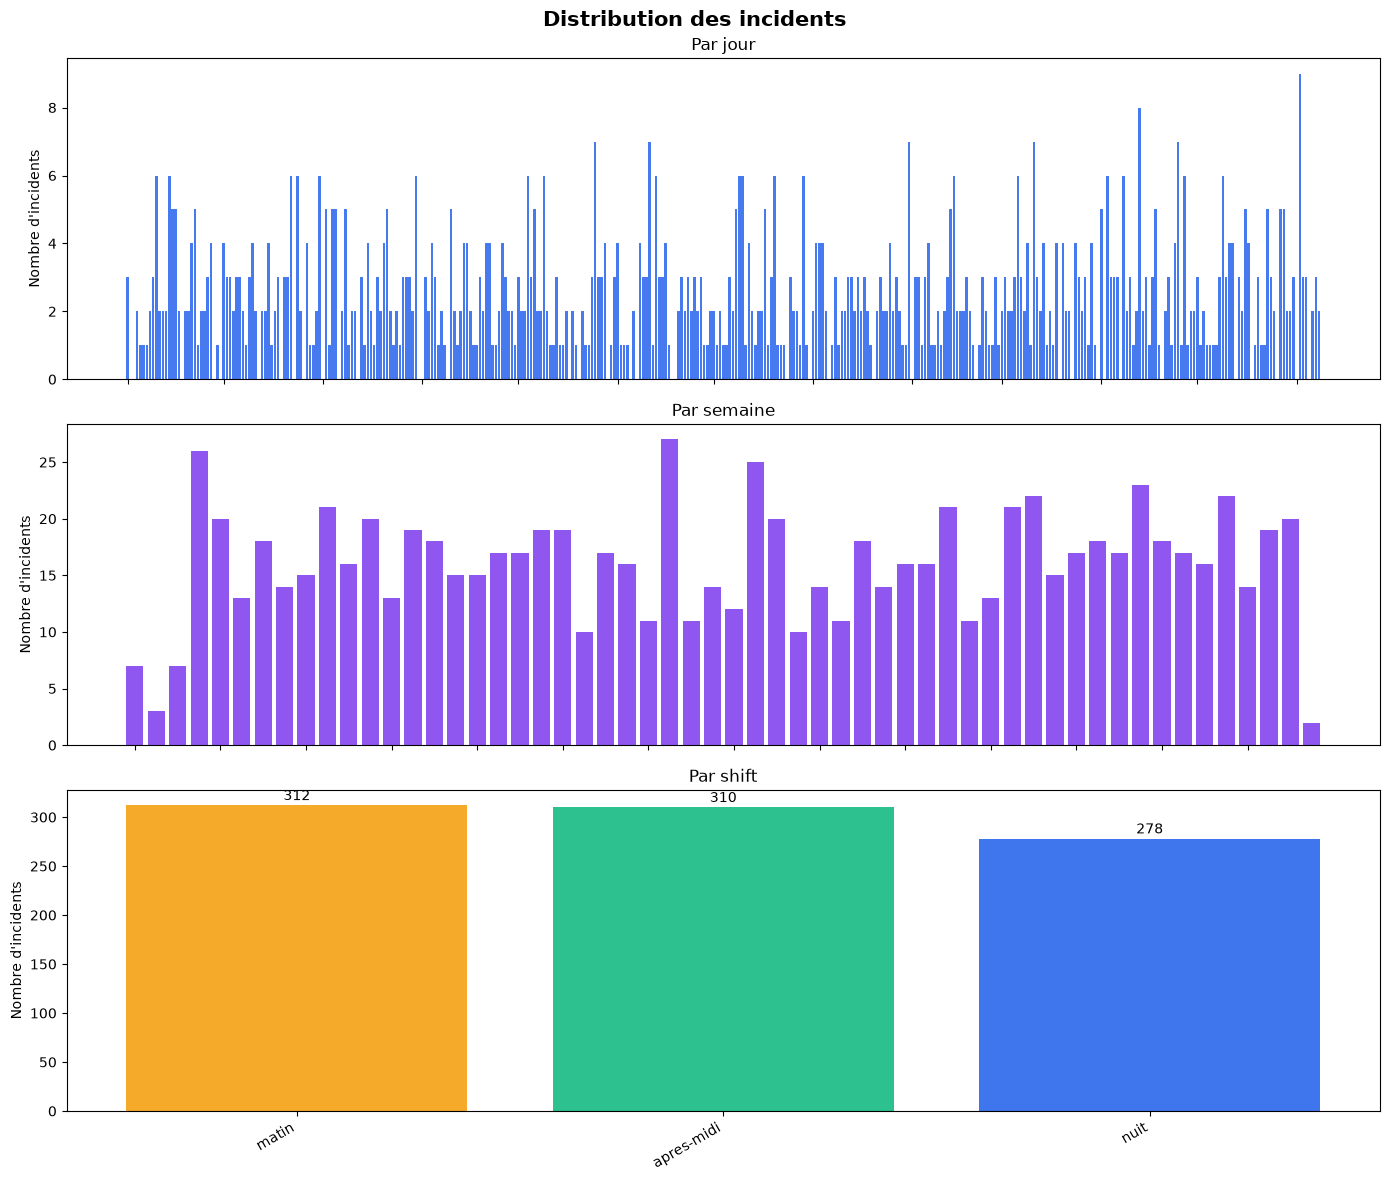

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Préparation des colonnes temporelles ──────────────────────
datas["datetime"]  = pd.to_datetime(datas["date"].astype(str) + " " + datas["time"])
datas["date"]      = pd.to_datetime(datas["date"])
datas["year_week"] = datas["datetime"].dt.strftime("%Y-W%V")

# ── Figure avec 3 sous-graphes ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Distribution des incidents", fontsize=15, fontweight="bold")

# 1. Par jour
daily = datas.groupby("date").size().reset_index(name="count")
axes[0].bar(daily["date"], daily["count"], color="#2563EB", width=0.8, alpha=0.85)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].set_title("Par jour")
axes[0].set_ylabel("Nombre d'incidents")
fig.autofmt_xdate(rotation=30)

# 2. Par semaine
weekly = datas.groupby("year_week").size().reset_index(name="count")
axes[1].bar(weekly["year_week"], weekly["count"], color="#7C3AED", alpha=0.85)
axes[1].set_xticks(range(0, len(weekly), 4))
axes[1].set_xticklabels(weekly["year_week"].iloc[::4], rotation=45, ha="right", fontsize=8)
axes[1].set_title("Par semaine")
axes[1].set_ylabel("Nombre d'incidents")

# 3. Par shift
shift_colors = {"matin": "#F59E0B", "apres-midi": "#10B981", "nuit": "#2563EB"}
shift_data   = datas["shift"].value_counts().reindex(["matin", "apres-midi", "nuit"])
bars = axes[2].bar(shift_data.index, shift_data.values,
                   color=[shift_colors[s] for s in shift_data.index], alpha=0.88)
for bar, val in zip(bars, shift_data.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha="center", va="bottom", fontsize=10)
axes[2].set_title("Par shift")
axes[2].set_ylabel("Nombre d'incidents")

plt.tight_layout()
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "distribution_incidents.png", bbox_inches="tight")
plt.show()

## Production d'un graphe de corrélation incidents / signaux,

Répertoire créé : artifacts\ingestions\incidents\202606161751


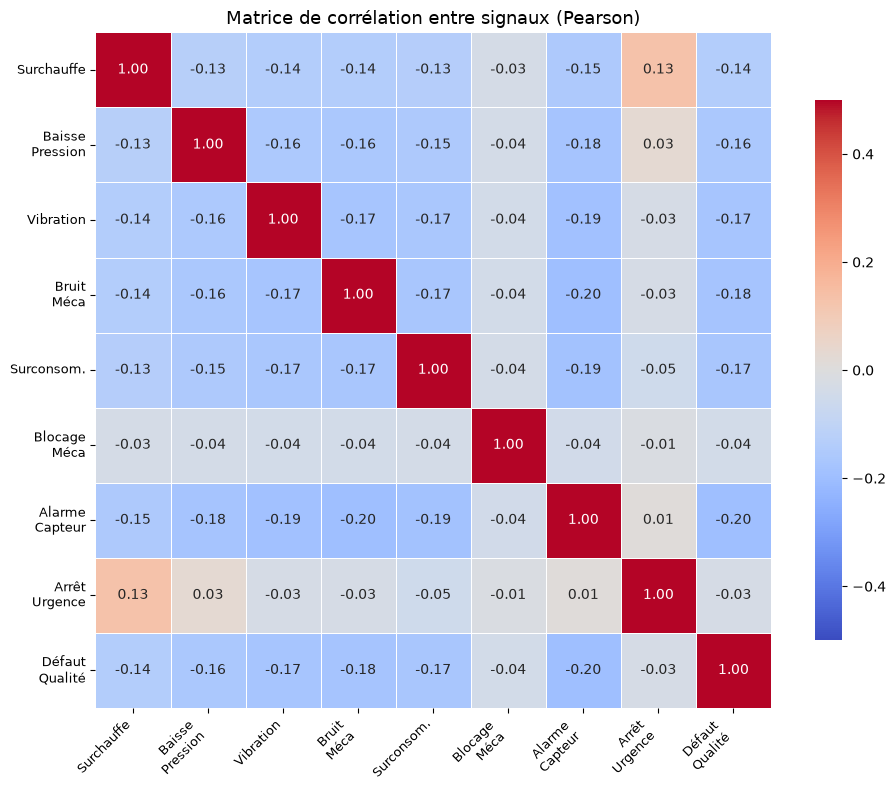

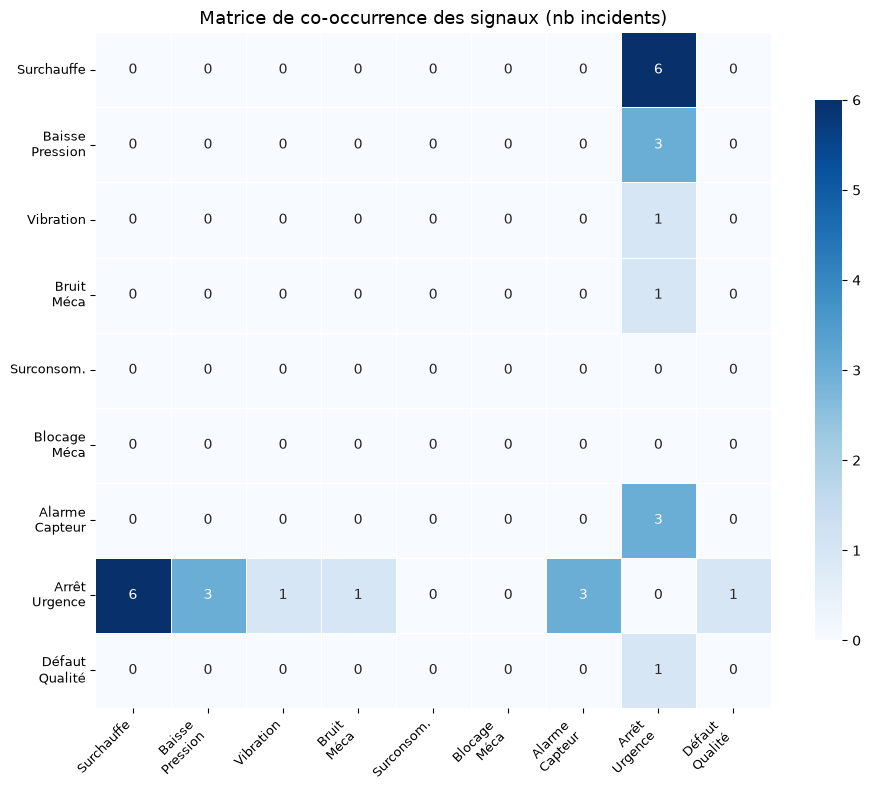

In [30]:
import seaborn as sns

# ── Colonnes signaux ──────────────────────────────────────────
SIGNALS = [
    "type_surchauffe", "type_baisse_pression", "type_vibration",
    "type_bruit_mecanique", "type_surconsommation", "type_blocage_mecanique",
    "type_alarme_capteur", "type_arret_urgence", "type_defaut_qualite"
]
LABELS = [
    "Surchauffe", "Baisse\nPression", "Vibration", "Bruit\nMéca",
    "Surconsom.", "Blocage\nMéca", "Alarme\nCapteur", "Arrêt\nUrgence", "Défaut\nQualité"
]

# ══════════════════════════════════════════════════════════════
# GRAPHE 1 — Matrice de corrélation de Pearson
# ══════════════════════════════════════════════════════════════
corr_data = datas[SIGNALS].copy()
corr_data.columns = LABELS

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    vmin=-0.5, vmax=0.5,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Matrice de corrélation entre signaux (Pearson)", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
run_dir = create_ingestion_dir(base="artifacts/ingestions", topic="incidents")
plt.savefig(run_dir / "correlation_pearson.png", bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════
# GRAPHE 2 — Matrice de co-occurrence
# ══════════════════════════════════════════════════════════════
co_vals = corr_data.values.T @ corr_data.values  # produit matriciel
co_arr  = co_vals.copy()
np.fill_diagonal(co_arr, 0)                       # diagonale à 0 (auto-occurrence)
co_matrix = pd.DataFrame(co_arr, index=LABELS, columns=LABELS)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    co_matrix,
    ax=ax,
    annot=True, fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Matrice de co-occurrence des signaux (nb incidents)", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(run_dir / "correlation_cooccurrence.png", bbox_inches="tight")
plt.show()

## Lectures rapides des graphes
Distribution temporelle : charge relativement uniforme sur l'année, légères hausses visibles certaines semaines. Les 3 shifts sont équilibrés (matin 312, après-midi 310, nuit 278).

Histogramme signaux : type_surchauffe et type_alarme_capteur dominent. L'indice de confiance (% d'incidents avec un commentaire opérateur) est hétérogène — type_arret_urgence est le mieux documenté, type_surconsommation le moins.

Histogramme machines : distribution assez homogène entre machines, la sévérité moyenne reste proche de 1–2 sur toutes.

Corrélation : les signaux sont majoritairement indépendants (coefficients Pearson proches de 0), confirmant qu'un incident = généralement un signal unique. La co-occurrence révèle quelques paires actives à surveiller. *